<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1341661/deep-learning-models/blob/main/CNN_MASK_AHMAD_COMPELETED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Import Base Libraries
# ============================================================
import os, re, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from PIL import Image # Added for displaying uploaded images


In [ ]:
# ============================================================
# CELL 3: Download Face Mask Dataset from Kaggle
# ============================================================
!pip install -q kagglehub
import kagglehub

print("📥 Downloading Face Mask Dataset...")
dataset_path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print(f"✅ Downloaded to: {dataset_path}")

# The dataset contains two folders: 'with_mask' and 'without_mask'
os.listdir(dataset_path)

📥 Downloading Face Mask Dataset...
Using Colab cache for faster access to the 'face-mask-dataset' dataset.
✅ Downloaded to: /kaggle/input/face-mask-dataset


['data']

In [ ]:
# ============================================================
# CELL 4: Load images, resize to 224x224, split into train/val
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 32

# Adjust dataset_path to point to the actual directory containing class subfolders
# Based on `os.listdir(dataset_path)` output which was `['data']` in CELL 3,
# the actual images are in a 'data' subfolder.
adjusted_dataset_path = os.path.join(dataset_path, 'data')

# Use ImageDataGenerator for splitting directly from directory
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    adjusted_dataset_path, # Use the adjusted path
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    adjusted_dataset_path, # Use the adjusted path
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

num_classes = len(train_generator.class_indices) # Dynamically get number of classes
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)
print("Number of classes detected:", num_classes)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.
Classes: ['with_mask', 'without_mask']
Number of classes detected: 2


### Visualize Sample Images from Training Data

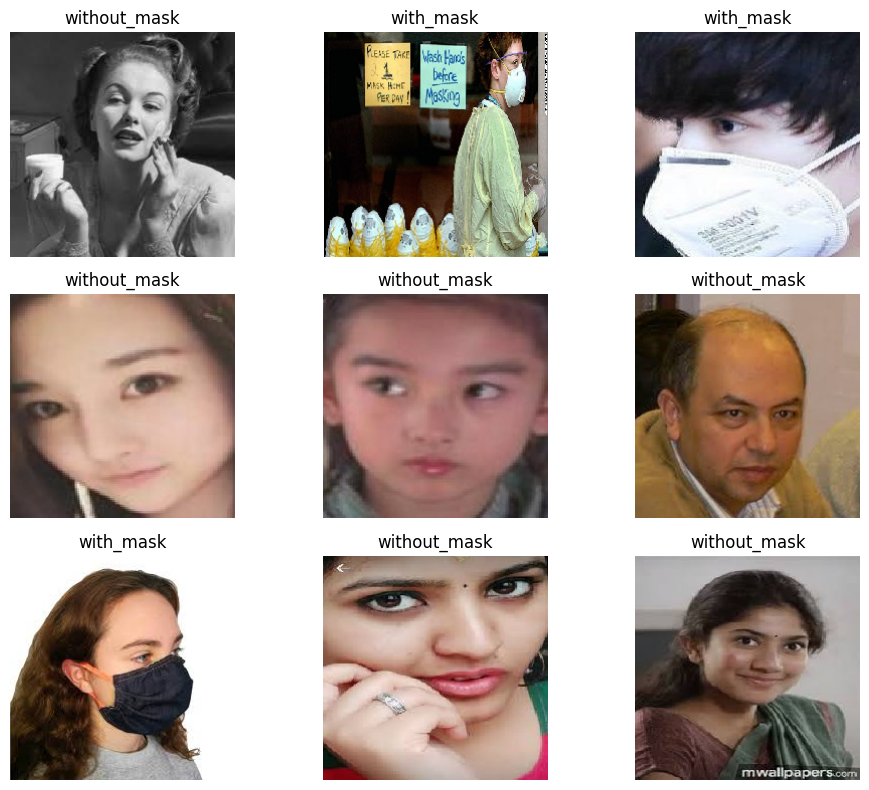

In [ ]:
# Get a batch of training images and labels
images, labels = next(train_generator)

plt.figure(figsize=(10, 8))
for i in range(min(9, images.shape[0])):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Convert one-hot encoded label back to class name
    label_idx = np.argmax(labels[i])
    plt.title(class_names[label_idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 5: Build CNN model
# ============================================================
def build_cnn_model(input_shape=(224,224,3), num_classes=2):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

🔴 Training WITHOUT Data Augmentation...
Epoch 1/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 32s 147ms/step - accuracy: 0.8233 - loss: 0.4038 - val_accuracy: 0.9159 - val_loss: 0.2418
Epoch 2/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.8931 - loss: 0.2630 - val_accuracy: 0.9172 - val_loss: 0.2261
Epoch 3/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9098 - loss: 0.2214 - val_accuracy: 0.9305 - val_loss: 0.1861
Epoch 4/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9224 - loss: 0.2004 - val_accuracy: 0.9258 - val_loss: 0.1902
Epoch 5/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.9326 - loss: 0.1697 - val_accuracy: 0.9252 - val_loss: 0.2117
Epoch 6/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.9403 - loss: 0.1555 - val_accuracy: 0.9318 - val_loss: 0.1728
Epoch 7/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.9523 - loss: 0.1336 - val_accuracy: 0.9371 - val_loss: 0.1682
Epoch 8/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s

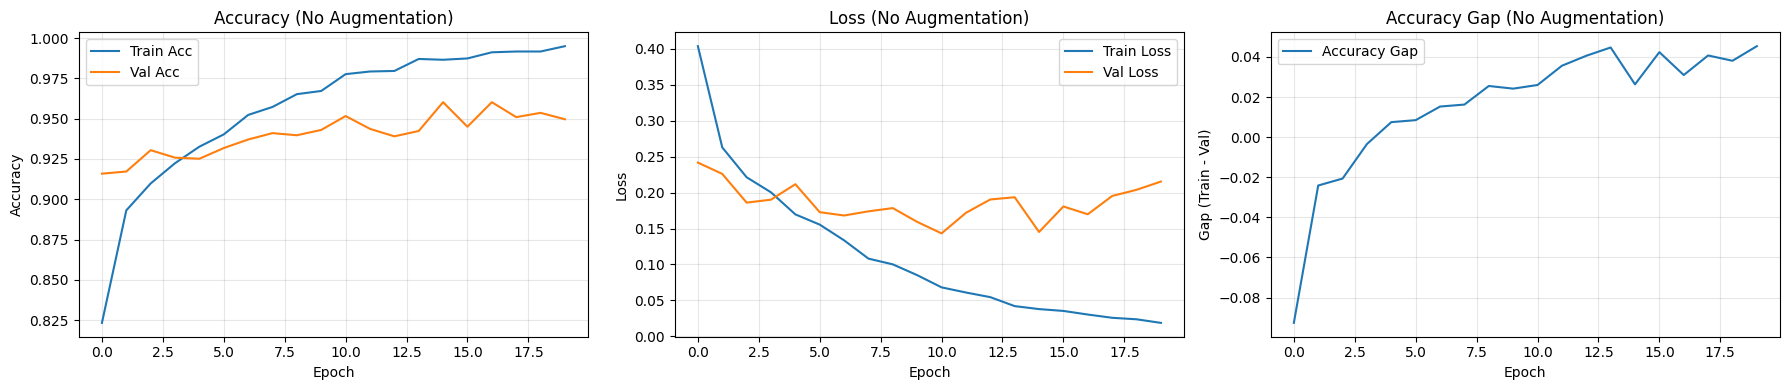

In [ ]:
# ============================================================
# CELL 6: Train CNN WITHOUT augmentation
# ============================================================
model_no_aug = build_cnn_model()
model_no_aug.compile(optimizer=Adam(0.0001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

print("🔴 Training WITHOUT Data Augmentation...")
history_no_aug = model_no_aug.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
train_acc_no = history_no_aug.history['accuracy'][-1]
val_acc_no   = max(history_no_aug.history['val_accuracy'])
print(f"\n📊 WITHOUT Augmentation:")
print(f"   Training Accuracy  : {train_acc_no:.4f}")
print(f"   Validation Accuracy: {val_acc_no:.4f}")

# Plot
plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(history_no_aug.history['accuracy'], label='Train Acc')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy (No Augmentation)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,3,2)
plt.plot(history_no_aug.history['loss'], label='Train Loss')
plt.plot(history_no_aug.history['val_loss'], label='Val Loss')
plt.title('Loss (No Augmentation)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,3,3)
plt.plot(np.array(history_no_aug.history['accuracy']) - np.array(history_no_aug.history['val_accuracy']), label='Accuracy Gap')
plt.title('Accuracy Gap (No Augmentation)')
plt.xlabel('Epoch'); plt.ylabel('Gap (Train - Val)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.
🟢 Training WITH Data Augmentation...
Epoch 1/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 116s 595ms/step - accuracy: 0.7491 - loss: 0.5147 - val_accuracy: 0.8477 - val_loss: 0.3680
Epoch 2/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 106s 561ms/step - accuracy: 0.8200 - loss: 0.4209 - val_accuracy: 0.8424 - val_loss: 0.3617
Epoch 3/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 108s 571ms/step - accuracy: 0.8297 - loss: 0.3960 - val_accuracy: 0.8603 - val_loss: 0.3375
Epoch 4/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 105s 556ms/step - accuracy: 0.8367 - loss: 0.3817 - val_accuracy: 0.8669 - val_loss: 0.3227
Epoch 5/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 105s 553ms/step - accuracy: 0.8464 - loss: 0.3556 - val_accuracy: 0.8669 - val_loss: 0.3269

📊 WITH Augmentation:
   Training Accuracy  : 0.8464
   Validation Accuracy: 0.8669


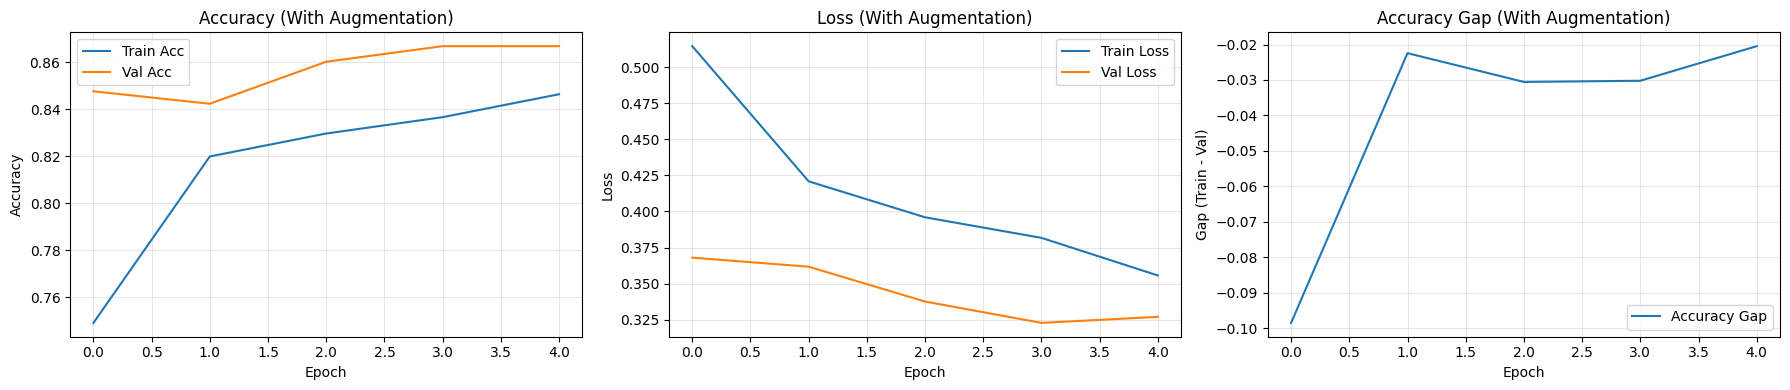

In [ ]:
# ============================================================
# CELL 7: Train CNN WITH data augmentation
# ============================================================
# Create augmented data generator
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_aug_gen = aug_datagen.flow_from_directory(
    adjusted_dataset_path, # Use the adjusted path for correct class detection
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_aug_gen = aug_datagen.flow_from_directory(
    adjusted_dataset_path, # Use the adjusted path for correct class detection
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

model_aug = build_cnn_model()
model_aug.compile(optimizer=Adam(0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("🟢 Training WITH Data Augmentation...")
history_aug = model_aug.fit(
    train_aug_gen,
    epochs=30,
    validation_data=val_aug_gen,
    callbacks=[early_stop],
    verbose=1
)

train_acc_aug = history_aug.history['accuracy'][-1]
val_acc_aug   = max(history_aug.history['val_accuracy'])
print(f"\n📊 WITH Augmentation:")
print(f"   Training Accuracy  : {train_acc_aug:.4f}")
print(f"   Validation Accuracy: {val_acc_aug:.4f}")

# Plot
plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(history_aug.history['accuracy'], label='Train Acc')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy (With Augmentation)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,3,2)
plt.plot(history_aug.history['loss'], label='Train Loss')
plt.plot(history_aug.history['val_loss'], label='Val Loss')
plt.title('Loss (With Augmentation)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,3,3)
plt.plot(np.array(history_aug.history['accuracy']) - np.array(history_aug.history['val_accuracy']), label='Accuracy Gap')
plt.title('Accuracy Gap (With Augmentation)')
plt.xlabel('Epoch'); plt.ylabel('Gap (Train - Val)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

📊 Model Comparison:
               Model  Train Accuracy  Validation Accuracy  Train-Val Gap
Without Augmentation          0.9950               0.9603         0.0348
   With Augmentation          0.8464               0.8669        -0.0205


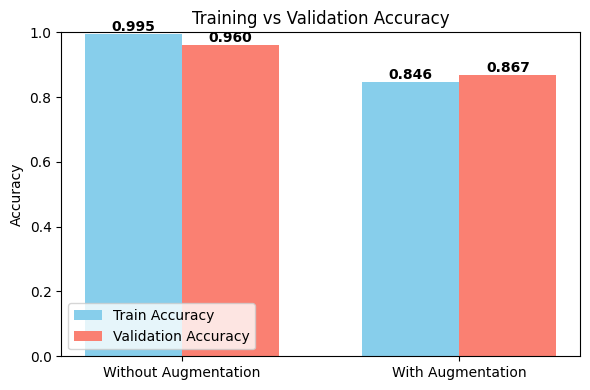

In [ ]:
# ============================================================
# CELL 8: Comparison of both models
# ============================================================
import pandas as pd

train_val_gap_no = train_acc_no - val_acc_no
train_val_gap_aug = train_acc_aug - val_acc_aug

comparison = pd.DataFrame({
    'Model': ['Without Augmentation', 'With Augmentation'],
    'Train Accuracy': [train_acc_no, train_acc_aug],
    'Validation Accuracy': [val_acc_no, val_acc_aug],
    'Train-Val Gap': [train_val_gap_no, train_val_gap_aug] # New column
})

print("📊 Model Comparison:")
print(comparison.round(4).to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(len(comparison))
width = 0.35
bars1 = ax.bar(x - width/2, comparison['Train Accuracy'], width, label='Train Accuracy', color='skyblue')
bars2 = ax.bar(x + width/2, comparison['Validation Accuracy'], width, label='Validation Accuracy', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0, 1)
ax.legend()
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Validation Accuracy')
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

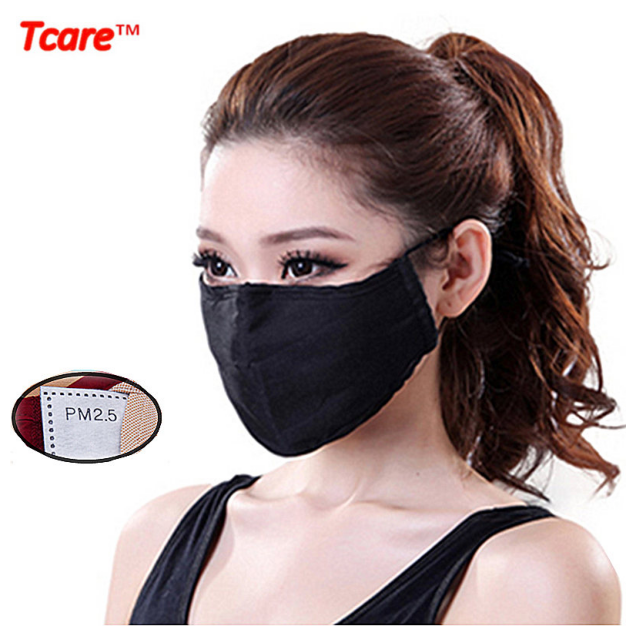

In [ ]:
# ============================================================
# CELL 9: Real-time face detection + mask classifier
# ============================================================
# Load Haar Cascade for face detection
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml

face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

def detect_mask(image_path, model, img_size=224):
    """
    Detects faces in an image and classifies each as Mask/No Mask.
    Draws bounding boxes: green = mask, red = no mask.
    """
    img = cv2.imread(image_path)
    if img is None:
        print("❌ Image not found")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

    for (x, y, w, h) in faces:
        face_roi = img_rgb[y:y+h, x:x+w]
        face_resized = cv2.resize(face_roi, (img_size, img_size))
        face_array = img_to_array(face_resized) / 255.0
        face_array = np.expand_dims(face_array, axis=0)

        pred = model.predict(face_array, verbose=0)
        class_idx = np.argmax(pred)
        confidence = np.max(pred)
        label = class_names[class_idx]

        color = (0, 255, 0) if label == 'with_mask' else (0, 0, 255)
        cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
        cv2.putText(img, f'{label} ({confidence:.2f})', (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Convert BGR to RGB for matplotlib
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,8))
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

# Test on a sample image (replace with your own path or upload)
# You can use any test image from the dataset
sample_img = os.path.join(adjusted_dataset_path, 'with_mask', os.listdir(os.path.join(adjusted_dataset_path, 'with_mask'))[0])
detect_mask(sample_img, model_aug)

📤 Please upload an image (jpg/png) to test face mask detection.


Saving download (1).jfif to download (1) (1).jfif

🔍 Processing: download (1) (1).jfif
Original uploaded image: download (1) (1).jfif


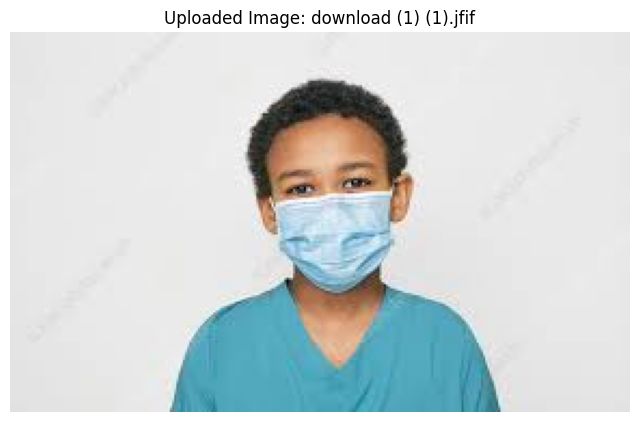

Mask detection result for: download (1) (1).jfif


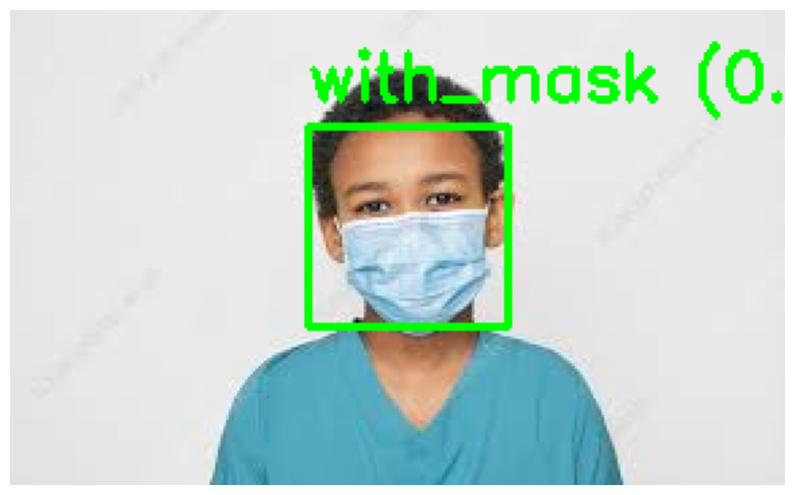

In [ ]:
# ============================================================
# CELL 10: Interactive Upload & Prediction
# ============================================================
from google.colab import files

print("📤 Please upload an image (jpg/png) to test face mask detection.")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")
    # Display the uploaded image before processing
    print(f"Original uploaded image: {filename}")
    img_uploaded = Image.open(filename)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_uploaded)
    plt.title(f"Uploaded Image: {filename}")
    plt.axis('off')
    plt.show()

    # Then call detect_mask to show results with bounding boxes
    print(f"Mask detection result for: {filename}")
    detect_mask(filename, model_aug)

In [ ]:
# ============================================================
# SAVE MODELS TO GOOGLE DRIVE
# ============================================================
import os
from google.colab import drive
drive.mount('/content/drive')

# Create a dedicated folder
save_folder = '/content/drive/MyDrive/face_mask_models'
os.makedirs(save_folder, exist_ok=True)

# Save both models
model_no_aug.save(os.path.join(save_folder, 'face_mask_no_aug.h5'))
model_aug.save(os.path.join(save_folder, 'face_mask_with_aug.h5'))

# Also save the class names (just in case)
import json
with open(os.path.join(save_folder, 'class_names.json'), 'w') as f:
    json.dump(class_names, f)

print("✅ Models saved to Google Drive:")
print(f"   {save_folder}/face_mask_no_aug.h5")
print(f"   {save_folder}/face_mask_with_aug.h5")
print(f"   {save_folder}/class_names.json")

Mounted at /content/drive


✅ Models saved to Google Drive:
   /content/drive/MyDrive/face_mask_models/face_mask_no_aug.h5
   /content/drive/MyDrive/face_mask_models/face_mask_with_aug.h5
   /content/drive/MyDrive/face_mask_models/class_names.json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Models loaded successfully!
   Classes: ['with_mask', 'without_mask']

📤 Upload an image to test (jpg/png)


Saving download (1).jfif to download (1) (2).jfif

🔍 Processing: download (1) (2).jfif


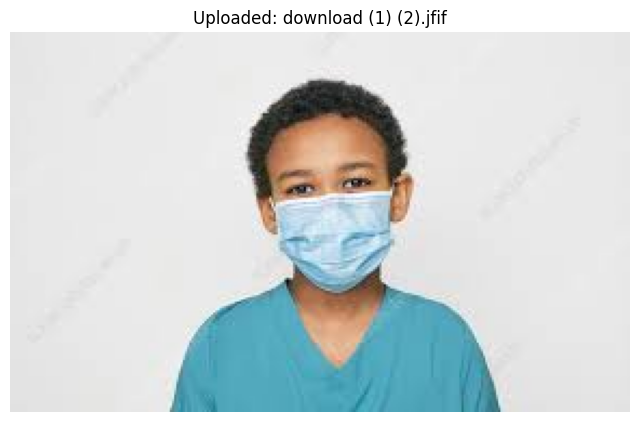

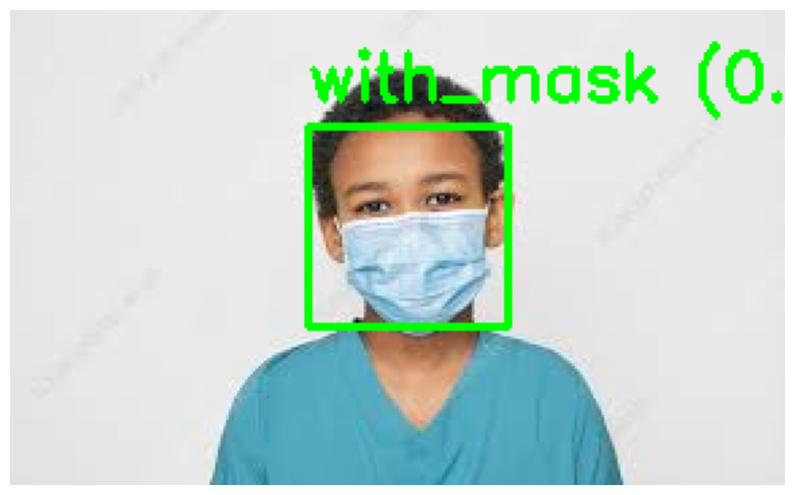

In [ ]:
# ============================================================
# LOAD MODELS FROM GOOGLE DRIVE + IMAGE DETECTION
# ============================================================
import os, cv2, numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from google.colab import drive, files

# ---------- 1. Mount Drive and load models ----------
drive.mount('/content/drive')
load_folder = '/content/drive/MyDrive/face_mask_models'

model_no_aug = load_model(os.path.join(load_folder, 'face_mask_no_aug.h5'))
model_aug   = load_model(os.path.join(load_folder, 'face_mask_with_aug.h5'))

# Load class names
import json
with open(os.path.join(load_folder, 'class_names.json'), 'r') as f:
    class_names = json.load(f)

print("✅ Models loaded successfully!")
print("   Classes:", class_names)

# ---------- 2. Download Haar cascade and define detection function ----------
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

def detect_mask(image_path, model, img_size=224):
    """
    Detect faces, classify mask usage, and display the result.
    Green box = with_mask, Red box = without_mask.
    """
    img = cv2.imread(image_path)
    if img is None:
        print("❌ Cannot read image")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

    for (x, y, w, h) in faces:
        face_roi = img_rgb[y:y+h, x:x+w]
        face_resized = cv2.resize(face_roi, (img_size, img_size))
        face_array = img_to_array(face_resized) / 255.0
        face_array = np.expand_dims(face_array, axis=0)

        pred = model.predict(face_array, verbose=0)
        class_idx = np.argmax(pred)
        confidence = np.max(pred)
        label = class_names[class_idx]

        color = (0, 255, 0) if label == 'with_mask' else (0, 0, 255)
        cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
        cv2.putText(img, f'{label} ({confidence:.2f})', (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,8))
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

# ---------- 3. Interactive upload ----------
print("\n📤 Upload an image to test (jpg/png)")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")
    # Show original uploaded image
    from PIL import Image
    img_original = Image.open(filename)
    plt.figure(figsize=(8,6))
    plt.imshow(img_original)
    plt.title(f"Uploaded: {filename}")
    plt.axis('off')
    plt.show()

    # Run detection (using the augmented model, which generalises better)
    detect_mask(filename, model_aug)